In [1]:
import kagglehub
import os
import random
from pathlib import Path
import torch
import math
import sys
import time

from abc import ABC, abstractmethod

import torch
import torchvision.models.detection.mask_rcnn
import copy

import datetime
import errno
import os
import time
from collections import defaultdict, deque, Counter

import torch
import torch.distributed as dist

import cv2
import json
import numpy as np
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import CocoDetection
import torchvision
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision

from torchvision.models.detection import RetinaNet_ResNet50_FPN_V2_Weights
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchvision.ops import box_iou

import torchvision.transforms.v2 as T
import torch.nn as nn
from pycocotools.coco import COCO

from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer,
    get_cosine_schedule_with_warmup
)

import albumentations as A

from rich.console import Console
from rich.table import Table


In [2]:
# Download latest version
dataset_path = Path(kagglehub.dataset_download("flyingfriedrice/8-gaze-directions-detection"))
dataset_str = str(dataset_path)

# print("Path to dataset files:", dataset_path)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 30

Data Exploration

In [3]:
# Investigate the dataset structure
def print_tree(path, max_depth=2, max_files=5):
    path = Path(path)

    def _walk(directory, prefix="", depth=0):
        if depth > max_depth:
            return

        items = sorted(directory.iterdir(), key=lambda x: (x.is_file(), x.name.lower()))

        shown = 0
        remaining = 0

        for item in items:
            if item.is_file():
                if shown >= max_files:
                    remaining += 1
                    continue
                shown += 1

            connector = "└── " if item == items[-1] else "├── "
            print(prefix + connector + item.name)

            if item.is_dir():
                extension = "    " if item == items[-1] else "│   "
                _walk(item, prefix + extension, depth + 1)

        if remaining > 0:
            print(prefix + f"└── ... ({remaining} more files)")

    print(path.name)
    _walk(path)
print_tree(dataset_path)

1
└── GazePerson2
    ├── test
    │   ├── _annotations.coco.json
    │   ├── p_back_side2_png.rf.d2a43e9e32c4e8379ff68134cb64b920.jpg
    │   ├── Screenshot-from-2025-12-09-11-58-00_png.rf.1fa1143cae08135014624bded275587a.jpg
    │   ├── Screenshot-from-2025-12-09-14-00-58_png.rf.3d68be61084093bffd969363b585e312.jpg
    │   ├── Screenshot-from-2025-12-09-14-01-15_png.rf.f677b1024f822943ebbbdfcd529b2f36.jpg
    │   └── ... (53 more files)
    ├── train
    │   ├── _annotations.coco.json
    │   ├── p_back_png.rf.431bd104f9959c548a8b9d966010933d.jpg
    │   ├── p_side_png.rf.884a3b647eefa235934a36584c474e18.jpg
    │   ├── Screenshot-from-2025-11-04-20-42-04_png.rf.c5c8584547d9fe599ba52748af57dde5.jpg
    │   ├── Screenshot-from-2025-11-04-20-43-04_png.rf.35e5f265a521488af0d7bc3fc3902a81.jpg
    │   └── ... (399 more files)
    ├── valid
    │   ├── 2_png.rf.baa4052bcd6875110ee17fbcbbefb801.jpg
    │   ├── _annotations.coco.json
    │   ├── Screenshot-from-2025-11-04-20-47-24_png.rf.ef0

>> Image samples


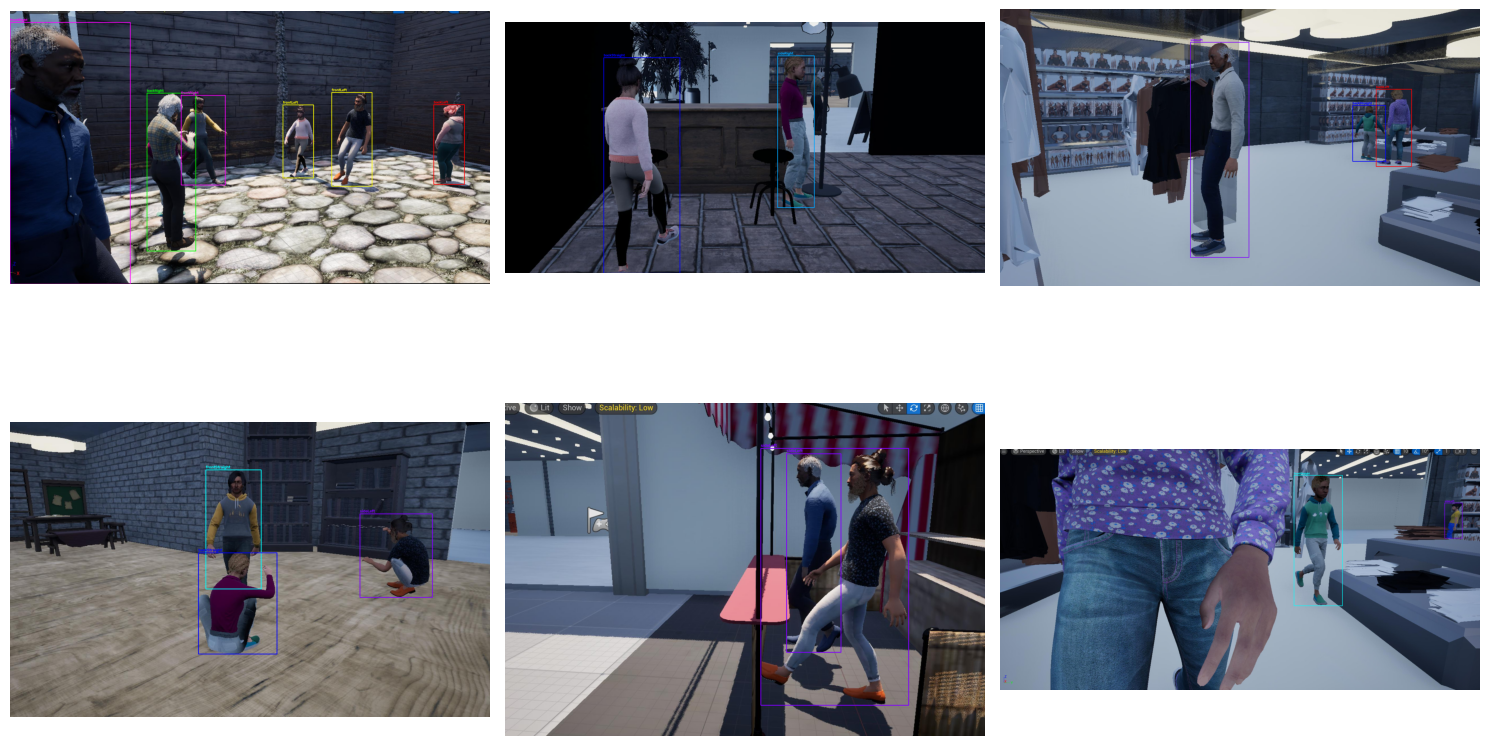

In [4]:
print(">> Image samples")

# BGR for OpenCV
colors = {
    1: (255, 0, 0),      # Blue
    2: (0, 255, 0),      # Green
    3: (0, 0, 255),      # Red
    4: (255, 255, 0),    # Cyan
    5: (255, 0, 255),    # Magenta
    6: (0, 255, 255),    # Yellow
    7: (128, 0, 255),    # Purple
    8: (0, 165, 255),    # Orange
    9: (180, 105, 255),  # Pink
}


train_dir = dataset_path / "GazePerson2" / "train"
with open(train_dir / "_annotations.coco.json", "r") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = {
    c["id"]: c["name"]
    for c in coco["categories"]
}

ann_dict = {}
for ann in annotations:
    ann_dict.setdefault(ann["image_id"], []).append(ann)

samples = random.sample(images, 6)

plt.figure(figsize=(15,10))
for i, img_info in enumerate(samples):
    image_path = train_dir / img_info["file_name"]
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    for ann in ann_dict.get(img_info["id"], []):
        x, y, w, h = ann["bbox"]
        x1 = int(x)
        y1 = int(y)
        x2 = int(x + w)
        y2 = int(y + h)
        category_id = ann["category_id"]
        color = colors.get(category_id, (255,255,255))  # default white

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            color,
            2
        )

        cv2.putText(
            image,
            categories[category_id],
            (x1, max(20, y1-5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.axis("off")

plt.tight_layout()

In [5]:
splits = ["train", "valid", "test"]
summary = []

for split in splits:
    annotation_file = dataset_path / "GazePerson2" / split / "_annotations.coco.json"
    with open(annotation_file, "r") as f:
        coco = json.load(f)
    summary.append({
        "Split": split.capitalize(),
        "Images": len(coco["images"]),
        "Annotations": len(coco["annotations"]),
        "Classes": len(coco["categories"])
    })
summary_df = pd.DataFrame(summary)

summary_df

,Split,Images,Annotations,Classes
0,Train,403,1153,9
1,Valid,115,357,9
2,Test,57,180,9


>>> The number of images:
train: 403 images
valid: 115 images
test: 57 images

>>> The number of annotations:


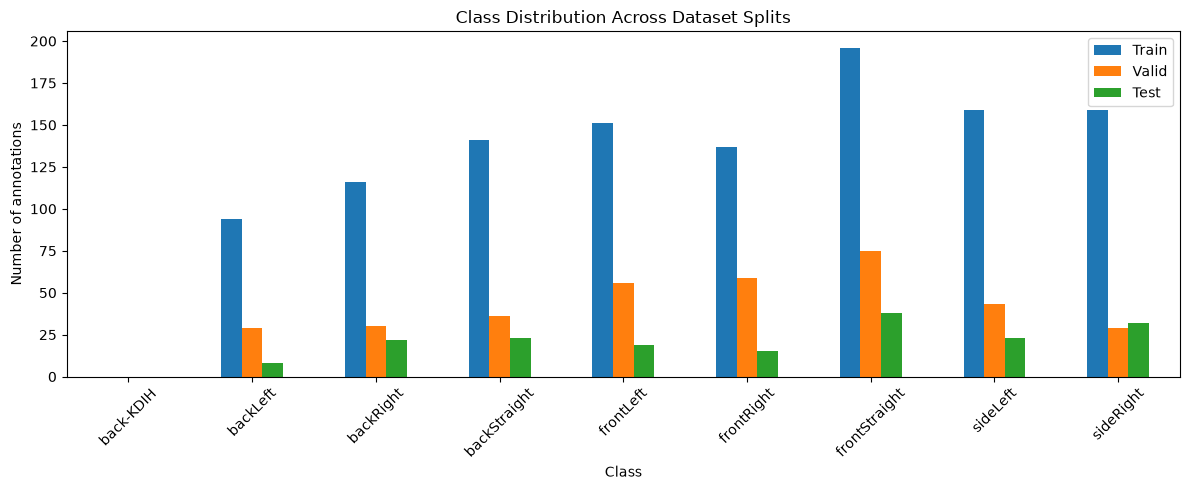

,Train,Valid,Test
back-KDIH,0.0,0.0,0.0
backLeft,8.2,8.1,4.4
backRight,10.1,8.4,12.2
backStraight,12.2,10.1,12.8
frontLeft,13.1,15.7,10.6
frontRight,11.9,16.5,8.3
frontStraight,17.0,21.0,21.1
sideLeft,13.8,12.0,12.8
sideRight,13.8,8.1,17.8


,Split,Width,Height,Resolution,Mode
0,train,1480,946,1480x946,RGB
1,train,2306,1121,2306x1121,RGB
2,train,1732,1123,1732x1123,RGB
3,train,1842,1181,1842x1181,RGB
4,train,2362,1415,2362x1415,RGB


In [6]:
image_stats = []

splits = ["train", "valid", "test"]

# number of images
print(">>> The number of images:")
for split in splits:
    n = len(list((dataset_path / "GazePerson2" / split ).glob("*")))
    print(f"{split}: {n-1} images")

# number of annotations
print("\n>>> The number of annotations:")
class_counts = {}

for split in splits:
    split_dir = dataset_path / "GazePerson2" / split
    with open(split_dir / "_annotations.coco.json") as f:
        coco = json.load(f)

    categories = {c["id"]: c["name"] for c in coco["categories"]}
    counter = Counter()
    for ann in coco["annotations"]:
        counter[ann["category_id"]] += 1

    class_counts[split] = {
        categories[k]: counter[k]
        for k in sorted(categories)
    }

    # image statistics
    for image_path in split_dir.glob("*.jpg"):

        with Image.open(image_path) as img:
            width, height = img.size
            mode = img.mode

        image_stats.append({
            "Split": split,
            "Width": width,
            "Height": height,
            "Resolution": f"{width}x{height}",
            "Mode": mode
        })

df = pd.DataFrame(class_counts)
df.columns = ["Train", "Valid", "Test"]
ax = df.plot.bar(figsize=(12,5))
ax.set_ylabel("Number of annotations")
ax.set_xlabel("Class")
ax.set_title("Class Distribution Across Dataset Splits")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Convert counts to percentages within each split
df_percent = df.div(df.sum(axis=0), axis=1) * 100
df_percent = df_percent.round(1)
display(df_percent)


# Display image stats
image_stats = pd.DataFrame(image_stats)
image_stats.head()

## Canonical Dataset

Clean the background class from canonical dataset because our models will need different background indeces


In [7]:
class GazeDetection(Dataset):
    def __init__(self, root_string, ann_file, transform):
        self.root = root_string
        self.annFile = ann_file
        self.transform = transform
        
        self.coco = COCO(self.annFile)
        self.ids = list(sorted(self.coco.imgs.keys()))

        real_cat_ids = sorted(self.coco.getCatIds())
        real_cat_ids = [cid for cid in real_cat_ids if cid != 0]
        self.catid2label = {cid: i for i, cid in enumerate(real_cat_ids)}
        self.id2label = self.get_id2label()

        
    def _load_image(self, id):
        path = self.coco.loadImgs(id)[0]["file_name"]
        return Image.open(os.path.join(self.root, path)).convert("RGB")
    
    def _load_target(self, image_id):
        ann_ids = self.coco.getAnnIds(image_id)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []

        for a in anns:
            category_id = a["category_id"]

            # skip Roboflow background category
            if category_id == 0:
                continue

            # remap remaining categories
            label = self.catid2label[category_id]

            x, y, w, h = a["bbox"]

            if w <= 0 or h <= 0:
                continue

            x1, y1, x2, y2 = x, y, x + w, y + h

            boxes.append([x1, y1, x2, y2])
            labels.append(label)

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor(image_id, dtype=torch.int64)
        }

        return target


    def __getitem__(self, idx):
        image_id = self.ids[idx]
        image = self._load_image(image_id)
        annotations = self._load_target(image_id)

        if self.transform is not None:
            image, annotations = self.transform(image, annotations)
        
        return image, annotations
    
   
    def __len__(self):
        return len(self.ids)
    
    
    def get_class_names(self):
        label2name = {
            label: self.coco.cats[cid]["name"]
            for cid, label in self.catid2label.items()
        }
        return [label2name[i] for i in range(len(label2name))]
    
    # wrapper for actually making the classname:str - class:int
    def get_id2label(self):
        names = self.get_class_names()
        return {i: name for i, name in enumerate(names)}
        
    @staticmethod
    def collate_fn(batch):
        # Since each image can have a different number of bounding boxes, stack the images but keep targets as a list.
        images = [item[0] for item in batch]
        targets = [item[1] for item in batch]
        return images, targets

In [8]:
train_dataset = GazeDetection(dataset_str + "/GazePerson2/train/", dataset_str + "/GazePerson2/train/_annotations.coco.json", None)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=GazeDetection.collate_fn
)



loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [9]:
train_dataset = GazeDetection(
    dataset_str + "/GazePerson2/train/",
    dataset_str + "/GazePerson2/train/_annotations.coco.json",
    None
)

# 1. What the mapping itself claims
print("catid2label mapping:", train_dataset.catid2label)
print("Number of mapped classes:", len(train_dataset.catid2label))

# 2. What labels ACTUALLY show up when you iterate the dataset
all_labels = set()
for i in range(len(train_dataset)):
    _, target = train_dataset[i]
    all_labels.update(target["labels"].tolist())

print("Unique labels actually produced:", sorted(all_labels))
print("Count:", len(all_labels))
assert sorted(all_labels) == list(range(8)), f"Expected labels 0-7, got {sorted(all_labels)}"

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
catid2label mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}
Number of mapped classes: 8
Unique labels actually produced: [0, 1, 2, 3, 4, 5, 6, 7]
Count: 8


In [10]:
images, targets = next(iter(train_loader))

for t in targets:
    print(torch.unique(t["labels"]))

tensor([7])
tensor([2])
tensor([3, 4])
tensor([1, 7])


In [11]:
# @interface
class BaseModelAdapter(nn.Module, ABC):
    def __init__(self,  dataset_id2label: dict[int, str], device=DEVICE):
        super().__init__()
        self.id2label = self.build_id2label(dataset_id2label)
        self.output_classes = len(self.id2label)
        self.device = device
        self.has_background_class = (self.id2label.get(0) == "background")

    # Must return a unified loss float tensor.
    @abstractmethod
    def forward_train(self, images, annotations):
        pass
    
    # Convert canonical dataset format into model specific format
    @abstractmethod
    def prepare_item(self, images, annotations):
        pass

    # This is a safety-fct which will require users to check their model inputs
    @abstractmethod
    def build_id2label(self, dataset_id2label: dict[int, str]) -> dict[int, str]:
        pass

    @abstractmethod
    def eval_for_validation(self):
        self.model.eval()


    # utility method for deriving annotations for prepare_item
    def _get_annotations(self, images, annotations):
        targets = []
        for ann, img in zip(annotations, images):
            boxes = ann["boxes"].detach().clone().to(self.device, dtype=torch.float32)
            if boxes.numel() == 0:
                boxes = boxes.reshape(0, 4)
            assert boxes.ndim == 2 and boxes.shape[1] == 4, \
                f"Malformed boxes tensor: {boxes.shape}"          

            labels = (ann["labels"].detach().clone()).to(self.device, dtype=torch.int64)
            assert labels.min() >= 0 and labels.max() <= self.output_classes - 1, \
                f"Label out of range: min={labels.min().item()}, " \
                f"max={labels.max().item()}, expected [0, {self.output_classes - 1}]"

            targets.append({
                "image_id": int(ann["image_id"]),   # avoid type error if accidentially became 0-dim tensor (but like it shouldn't)
                "boxes": boxes,
                "labels": labels
            })

        return targets
    

    # useful particularly for val
    @torch.no_grad()
    def predict(self, images, score_threshold=0.5):
        self.model.eval()
        tensor_images, _ = self.prepare_item(images, annotations=None)
        outputs = self.model(tensor_images)
        for out in outputs:
            keep = out["scores"] >= score_threshold
            out["boxes"] = out["boxes"][keep].to(self.device)
            out["labels"] = out["labels"][keep].to(self.device)
            out["scores"] = out["scores"][keep].to(self.device)
        return outputs
        
    # utility method
    @staticmethod
    def convert_voc2coco(bbox):
        x1, y1, x2, y2 = bbox
        w = x2 - x1
        h = y2 - y1
        return [x1, y1, w, h]

In [12]:
# utility method
def plot_predictions(img, results, dataset, threshold=0.5, ax=None):
    # 1. Build the label-to-name mapping dynamically using your dataset's structures
    label_to_name = {}
    for cat_id, cat_info in dataset.coco.cats.items():
        if cat_id in dataset.catid2label:
            mapped_label = dataset.catid2label[cat_id]
            label_to_name[mapped_label] = cat_info["name"]

    # 2. Setup the plot if an axis isn't provided
    if ax is None:
        fig, ax = plt.subplots(1, figsize=(12, 8))
    
    ax.imshow(img)
    
    # 3. Extract predictions
    pred_boxes = results["boxes"].cpu()
    pred_scores = results["scores"].cpu()
    pred_labels = results["labels"].cpu()
    
    # 4. Draw predicted bounding boxes and labels
    for box, score, label_tensor in zip(pred_boxes, pred_scores, pred_labels):
        score_val = score.item()
        if score_val < threshold:
            continue
            
        label_id = label_tensor.item()
        class_name = label_to_name.get(label_id, f"Class {label_id}")
        
        # Convert [xmin, ymin, xmax, ymax] to [xmin, ymin, width, height] for matplotlib
        xmin, ymin, xmax, ymax = box.tolist()
        width, height = xmax - xmin, ymax - ymin
        
        # Draw the bounding box
        rect = patches.Rectangle(
            (xmin, ymin), width, height, 
            linewidth=2, edgecolor="red", facecolor="none"
        )
        ax.add_patch(rect)
        
        # Draw the text background and label
        ax.text(
            xmin, ymin - 5, 
            f"{class_name}: {score_val:.2f}", 
            color="white", 
            fontsize=10,
            bbox=dict(facecolor="red", alpha=0.6, edgecolor="none", pad=2)
        )
        
    ax.axis("off")
    
    if ax is None:
        plt.show()


# utility method train
def plot_train_val_loss_curve(train_losses, val_losses, title="Training vs. Validation Loss"):
    plt.plot(train_losses, label="Train", color="tab:blue")
    plt.plot(val_losses, label="Val", color="tab:orange")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(title)
    plt.show()


# utility method testdef plot_confusion_matrix(adapter, dataloader, id2label, include_background=True,

# utility method testdef plot_confusion_matrix(adapter, dataloader, id2label, include_background=True,
def plot_confusion_matrix(adapter, dataloader, id2label, include_background=True,
                           iou_threshold=0.5, score_threshold=0.5):
    # 1. Determine size and locate the existing background label
    tick_labels = [id2label[i] for i in sorted(id2label.keys())]
    size = len(tick_labels)

    bg_idx = None
    if include_background:
        bg_idx = next((k for k, v in id2label.items() if v.lower() == "background"), None)
        if bg_idx is None:
            raise ValueError("include_background is True, but 'background' string not found in id2label keys.")

    cm = torch.zeros((size, size), dtype=torch.int64)

    # 2. Process Predictions
    for images, annotations in tqdm(dataloader, desc="Building confusion matrix"):
        preds = adapter.predict(images)
        for pred, ann in zip(preds, annotations):
            # Filter predictions by confidence threshold
            keep = pred["scores"] >= score_threshold
            pred_boxes = pred["boxes"][keep]
            gt_boxes = ann["boxes"].to(pred_boxes.device)

            if include_background:
                pred_labels = pred["labels"][keep] + 1
                gt_labels = ann["labels"].to(pred_boxes.device) + 1
            else:
                pred_labels = pred["labels"][keep]
                gt_labels = ann["labels"].to(pred_boxes.device)

            matched_gt = set()
            if len(pred_boxes) and len(gt_boxes):
                ious = box_iou(pred_boxes, gt_boxes)
                for p_idx in range(len(pred_boxes)):
                    best_iou, g_idx = ious[p_idx].max(0)
                    g_idx_item = g_idx.item()
                    c = pred_labels[p_idx].item()
                    if best_iou >= iou_threshold and g_idx_item not in matched_gt:
                        matched_gt.add(g_idx_item)
                        r = gt_labels[g_idx_item].item()
                        cm[r, c] += 1
                    elif include_background:
                        cm[bg_idx, c] += 1  # False Positive
            elif include_background:  # No ground truths, but we have predictions
                for p_idx in range(len(pred_boxes)):
                    c = pred_labels[p_idx].item()
                    cm[bg_idx, c] += 1

            if include_background:  # Ground truths that were never matched (False Negatives)
                for g_idx in range(len(gt_boxes)):
                    if g_idx not in matched_gt:
                        r = gt_labels[g_idx].item()
                        cm[r, bg_idx] += 1

    # 3. Plotting (unchanged)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm.numpy(), cmap="Blues")
    ax.set_xticks(range(size))
    ax.set_yticks(range(size))
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")
    ax.set_yticklabels(tick_labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground truth")
    ax.set_title("Confusion Matrix")

    thresh = cm.max().item() / 2 if cm.max().item() > 0 else 1
    for i in range(size):
        for j in range(size):
            val = cm[i, j].item()
            ax.text(j, i, str(val), ha="center", va="center",
                     color="white" if val > thresh else "black")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()

    return cm

    
# mAP
def show_mAP(adapter_model, val_loader, include_background=False, device=DEVICE):
    metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)
    id2label = adapter_model.id2label

    for images, annotations in val_loader:
        preds = adapter_model.predict(images)   # they r shifted to device by predict
        targets = [
            {"boxes": a["boxes"].to(device), "labels": a["labels"].to(device)}
            for a in annotations
        ]
        metric.update(preds, targets)

    results = metric.compute()

    console = Console()
    table = Table(title="Object Detection Evaluation Results")
    table.add_column("Metric / Class", justify="left", style="cyan")
    table.add_column("Value", justify="right", style="green")

    table.add_row("Global mAP (0.5:0.95)", f"{results['map'].item():.4f}")
    table.add_row("mAP @ 50", f"{results['map_50'].item():.4f}")
    table.add_row("mAP @ 75", f"{results['map_75'].item():.4f}")
    table.add_section()

    per_class_map = results["map_per_class"]
    if per_class_map.numel() > 0 and (per_class_map != -1).any():
        for idx, score in enumerate(per_class_map):
            class_name = id2label.get(idx, f"Class_{idx}") if id2label else f"Class_{idx}"

            # Only skip if this index's label is actually "background"
            if class_name.lower() == "background" and not include_background:
                continue

            score_val = score.item()
            if score_val < 0:
                table.add_row(class_name, "N/A", style="dim")
                continue

            table.add_row(class_name, f"{score_val:.4f}")
    else:
        table.add_row("Per-class Metrics", "Not available", style="dim")

    console.print(table)

# Augmentation and Preprocessing

In [13]:
train_augmentation_and_transform = A.Compose(
    [
        A.Perspective(scale=(0.02, 0.05), p=0.15),
        A.HorizontalFlip(p=0.0),    # You must never flip horizontally without changing the labels, too
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
            A.CLAHE(clip_limit=3.0, p=1.0),
        ], p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.1),
        A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.15),
        A.ToGray(p=0.10),
        A.GaussNoise(var_limit=(5.0, 20.0), p=0.15),
        A.ImageCompression(quality_range=(75, 100), p=0.15),

        A.SafeRotate(limit=10, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.8),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=25
    ),
)

valid_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=1
    ),
)

# wrap into Albumentations as dataset expects
class AlbumentationsTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, image, target):
        image = np.array(image)

        output = self.transform(
            image=image,
            bboxes=target["boxes"].numpy(),
            category=target["labels"].numpy(),
        )

        image = Image.fromarray(output["image"])

        target = {
            "boxes": torch.as_tensor(output["bboxes"], dtype=torch.float32),
            "labels": torch.as_tensor(output["category"], dtype=torch.int64),
            "image_id": target["image_id"]
        }

        return image, target

/tmp/ipykernel_157762/945624060.py:12: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.15),
/tmp/ipykernel_157762/945624060.py:15: UserWarning: Argument(s) 'value' are not valid for transform SafeRotate
  A.SafeRotate(limit=10, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.8),


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


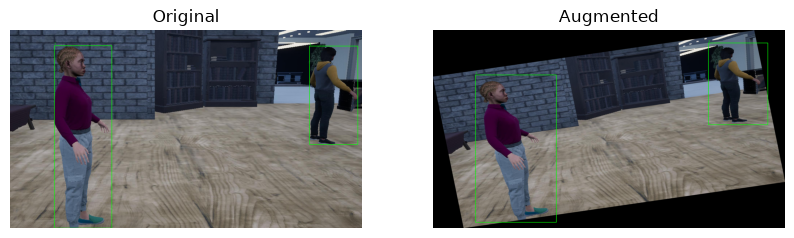

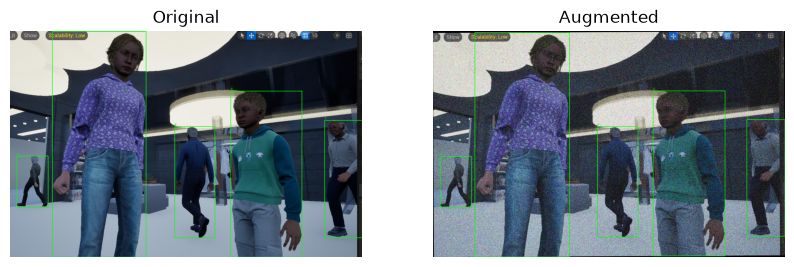

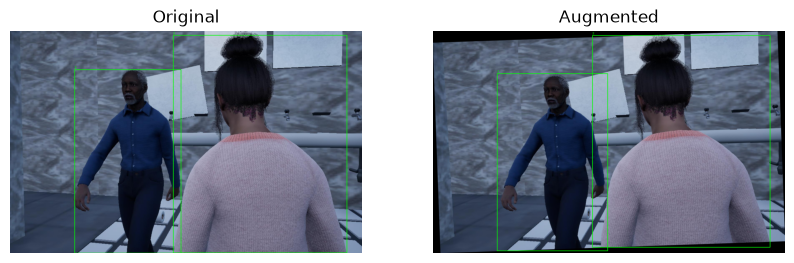

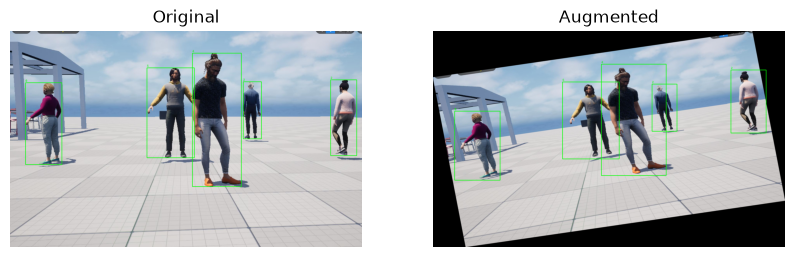

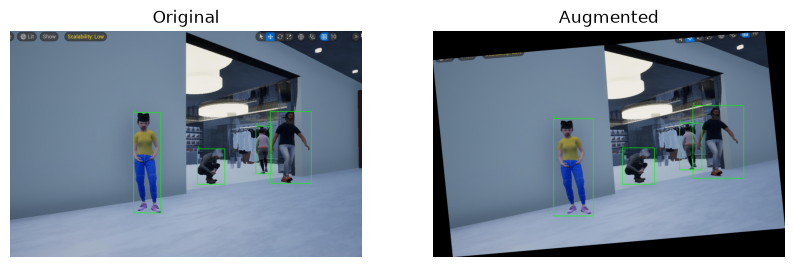

In [14]:
IMAGE_COUNT = 5

orig_dataset = GazeDetection(
    dataset_str + "/GazePerson2/train/",
    dataset_str + "/GazePerson2/train/_annotations.coco.json",
    transform=None,
)

aug_dataset = GazeDetection(
    dataset_str + "/GazePerson2/train/",
    dataset_str + "/GazePerson2/train/_annotations.coco.json",
    transform=AlbumentationsTransform(train_augmentation_and_transform),
)

def draw_boxes(image, boxes, labels):
    img = np.array(image).copy()
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, str(int(label)), (x1, max(y1 - 5, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    return img

for i in range(IMAGE_COUNT):
    orig_image, orig_target = orig_dataset[i]
    aug_image, aug_target = aug_dataset[i]  # same index -> same source sample

    original_vis = draw_boxes(orig_image, orig_target["boxes"], orig_target["labels"])
    augmented_vis = draw_boxes(aug_image, aug_target["boxes"], aug_target["labels"])

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original_vis); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(augmented_vis); ax[1].set_title("Augmented"); ax[1].axis("off")
    plt.show()

# Train Faster-RCNN

In [15]:
train_dataset = GazeDetection(
    dataset_str + "/GazePerson2/train/",
    dataset_str + "/GazePerson2/train/_annotations.coco.json",
    AlbumentationsTransform(train_augmentation_and_transform),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=GazeDetection.collate_fn
)



val_dataset = GazeDetection(
    dataset_str + "/GazePerson2/valid/",
    dataset_str + "/GazePerson2/valid/_annotations.coco.json",
    AlbumentationsTransform(valid_transform)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=GazeDetection.collate_fn
)



test_dataset = GazeDetection(
    dataset_str + "/GazePerson2/test/",
    dataset_str + "/GazePerson2/test/_annotations.coco.json",
    AlbumentationsTransform(valid_transform),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=GazeDetection.collate_fn
)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [16]:
# strongly simplified
def train_one_epoch(adapter_model, dataloader, optimizer, device=DEVICE, max_loss=1000.0, max_grad_norm=10.0):
    adapter_model.train()
    running_loss = 0.0
    pbar = tqdm(dataloader, desc="Training")
    for batch_idx, (images, annotations) in enumerate(pbar):
        optimizer.zero_grad()
        loss = adapter_model.forward_train(images, annotations)

        # catch NaN/Inf AND unreasonably large-but-finite losses (gradient explosion in progress)
        if not torch.isfinite(loss) or loss.item() > max_loss:
            print(f"\n[Warning] Loss is {loss.item()}, skipping batch {batch_idx}")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(adapter_model.parameters(), max_norm=max_grad_norm)
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"})
    epoch_loss = running_loss / len(dataloader)
    return epoch_loss


def validate_one_epoch(adapter_model, dataloader):
    adapter_model.eval_for_validation()   # let each adapter decide what "eval but still get losses" means
    running_val_loss = 0.0
    n_valid = 0
    pbar = tqdm(dataloader, desc="Validation", leave=False)
    with torch.no_grad():
        for images, annotations in pbar:
            loss = adapter_model.forward_train(images, annotations)
            if torch.isfinite(loss):
                running_val_loss += loss.item()
                n_valid += 1
    epoch_val_loss = running_val_loss / max(n_valid, 1)
    return epoch_val_loss

In [17]:
# handle the background class for torchvision by +1 shift of classes, so background class is at index 0
class FasterRCNNAdapter(BaseModelAdapter):
    def __init__(self, model, dataset_id2label, device=DEVICE):
        super().__init__(dataset_id2label=dataset_id2label, device=device)
        self.model = model

        print(f"Model: {self.model}\nHead classes (incl. background): {self.output_classes}\nDevice: {self.device}")

    # add background class at index 0; FasterRCNN expects float images in [0,1]
    def prepare_item(self, images, annotations):
        if annotations is not None:
            targets = self._get_annotations(images, annotations)
            for t in targets:
                t["labels"] = t["labels"] + 1
                if t["labels"].numel() > 0:
                    assert t["labels"].min() >= 1 and t["labels"].max() <= self.output_classes - 1, \
                        f"Label out of range after shift: min={t['labels'].min().item()}, " \
                        f"max={t['labels'].max().item()}, expected [1, {self.output_classes - 1}]"
        else:
            targets = None

        tensor_images = []
        for img in images:
            np_img = np.array(img, dtype=np.float32) / 255.0
            tensor_images.append(torch.from_numpy(np_img).permute(2, 0, 1).to(self.device))
        return tensor_images, targets
            

    def forward_train(self, images, annotations):
        tensor_images, targets = self.prepare_item(images, annotations)
        loss_dict = self.model(tensor_images, targets)
        return sum(loss for loss in loss_dict.values())
    

    def eval_for_validation(self):
        self.model.train()
        for m in self.model.modules():
            if isinstance(m, torch.nn.modules.batchnorm._BatchNorm):
                m.eval()   # keeps loss-dict behavior, but freezes running stats and uses eval-mode BN math
        
        
    def build_id2label(self, dataset_id2label):
        # torchvision FasterRCNN reserves index 0 for background
        return {0: "background", **{k + 1: v for k, v in dataset_id2label.items()}}
    
    @torch.no_grad()
    def predict(self, images, score_threshold=0.5):
        outputs = super().predict(images, score_threshold=score_threshold)
        for out in outputs:
            keep = out["labels"] != 0
            out["boxes"] = out["boxes"][keep]
            out["labels"] = out["labels"][keep] - 1
            out["scores"] = out["scores"][keep]
        return outputs


In [18]:
rcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)

 # get number of input features for the classifier
in_features = rcnn_model.roi_heads.box_predictor.cls_score.in_features

# replace the pre-trained head with a new one
rcnn_adapter = FasterRCNNAdapter(model=rcnn_model, dataset_id2label=train_dataset.id2label)
rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, rcnn_adapter.output_classes) 
rcnn_model.to(DEVICE)



Model: FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, 

<ul>
<li>(cls_score): Linear(in_features=1024, out_features=9, bias=True), 8 classes plus background class
<li>(bbox_pred): Linear(in_features=1024, out_features=36, bias=True), the previous 9 classes each giving 4 dimensions (x, y, w, h)
</ul>


In [19]:
# construct an optimizer
params = [p for p in rcnn_model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, 
                            lr=0.005,
                            momentum=0.9, 
                            weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                               step_size=3,
                                               gamma=0.1)

In [20]:
rcnn_adapter.id2label

{0: 'background',
 1: 'backLeft',
 2: 'backRight',
 3: 'backStraight',
 4: 'frontLeft',
 5: 'frontRight',
 6: 'frontStraight',
 7: 'sideLeft',
 8: 'sideRight'}

In [21]:
rcnn_train_losses, rcnn_val_losses = [], []
best_val_loss = float("inf")
best_epoch = None
rcnn_best = None
Path("models").mkdir(parents=True, exist_ok=True)

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
    train_loss = train_one_epoch(rcnn_adapter, train_loader, optimizer)
    val_loss = validate_one_epoch(rcnn_adapter, val_loader)
    rcnn_train_losses.append(train_loss)
    rcnn_val_losses.append(val_loss)

    print(f"Epoch {epoch+1} Complete | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        rcnn_best = copy.deepcopy(rcnn_adapter)
        torch.save(rcnn_best.model.state_dict(), "models/rcnn_trained_weights.pth")
        print(f"  -> New best model saved (val_loss={val_loss:.4f})")


--- Epoch 1/30 ---


Training: 100%|██████████| 101/101 [00:35<00:00,  2.87it/s, batch_loss=0.4275]


Epoch 1 Complete | Train Loss: 0.6472 | Val Loss: 0.4712
  -> New best model saved (val_loss=0.4712)

--- Epoch 2/30 ---


Training: 100%|██████████| 101/101 [00:33<00:00,  2.99it/s, batch_loss=0.2169]


Epoch 2 Complete | Train Loss: 0.4035 | Val Loss: 0.3624
  -> New best model saved (val_loss=0.3624)

--- Epoch 3/30 ---


...

Epoch 28 Complete | Train Loss: 0.1106 | Val Loss: 0.2619

--- Epoch 29/30 ---


Training: 100%|██████████| 101/101 [00:33<00:00,  2.99it/s, batch_loss=0.0983]


Epoch 29 Complete | Train Loss: 0.0977 | Val Loss: 0.2398

--- Epoch 30/30 ---


Training: 100%|██████████| 101/101 [00:34<00:00,  2.97it/s, batch_loss=0.1030]
                                                           

Epoch 30 Complete | Train Loss: 0.1003 | Val Loss: 0.2534


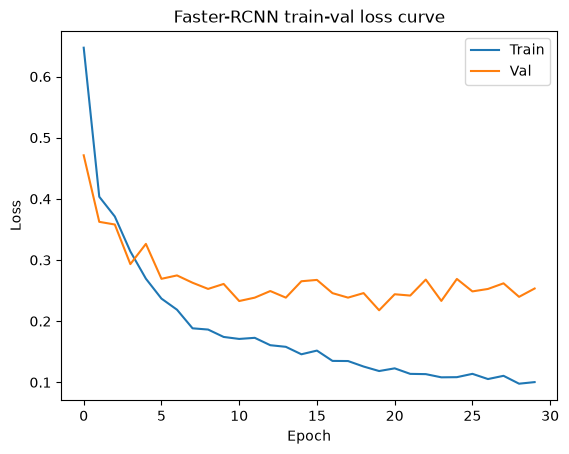

In [22]:
plot_train_val_loss_curve(rcnn_train_losses, rcnn_val_losses, "Faster-RCNN train-val loss curve")

In [23]:
show_mAP(rcnn_best, test_loader, True, DEVICE)

   Object Detection Evaluation    
             Results              
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric / Class        ┃  Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Global mAP (0.5:0.95) │ 0.6094 │
│ mAP @ 50              │ 0.7616 │
│ mAP @ 75              │ 0.7415 │
├───────────────────────┼────────┤
│ background            │ 0.7316 │
│ backLeft              │ 0.4814 │
│ backRight             │ 0.6663 │
│ backStraight          │ 0.4608 │
│ frontLeft             │ 0.6155 │
│ frontRight            │ 0.6341 │
│ frontStraight         │ 0.6569 │
│ sideLeft              │ 0.6285 │
└───────────────────────┴────────┘

Building confusion matrix: 100%|██████████| 15/15 [00:02<00:00,  6.28it/s]


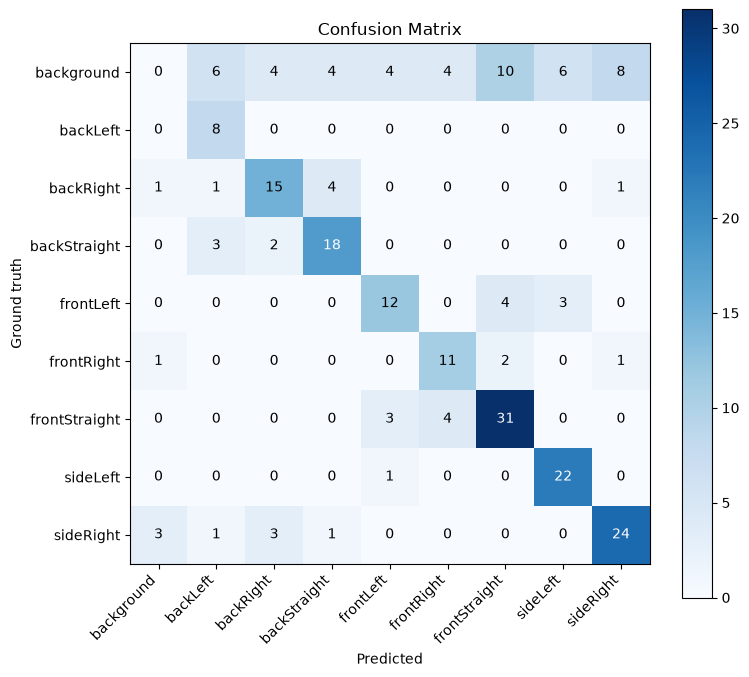

tensor([[ 0,  6,  4,  4,  4,  4, 10,  6,  8],
        [ 0,  8,  0,  0,  0,  0,  0,  0,  0],
        [ 1,  1, 15,  4,  0,  0,  0,  0,  1],
        [ 0,  3,  2, 18,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0, 12,  0,  4,  3,  0],
        [ 1,  0,  0,  0,  0, 11,  2,  0,  1],
        [ 0,  0,  0,  0,  3,  4, 31,  0,  0],
        [ 0,  0,  0,  0,  1,  0,  0, 22,  0],
        [ 3,  1,  3,  1,  0,  0,  0,  0, 24]])

In [24]:
plot_confusion_matrix(
    adapter=rcnn_best, 
    dataloader=test_loader, 
    id2label=rcnn_adapter.id2label, 
    include_background=True # Tracks background index 0 seamlessly
)

Sample how to reload

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-create the blank model & adapter setup
rcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=None) # No default weights
rcnn_adapter_reloaded = FasterRCNNAdapter(model=rcnn_model, dataset_id2label=train_dataset.id2label, device=device)

rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, rcnn_adapter_reloaded.output_classes)


# Load your trained weights straight into the adapter's model
rcnn_adapter_reloaded.model.load_state_dict(torch.load("models/rcnn_trained_weights.pth", map_location=device))
rcnn_adapter_reloaded.model.to(device)
print("Model is loaded and ready on:", device)


Model: FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias

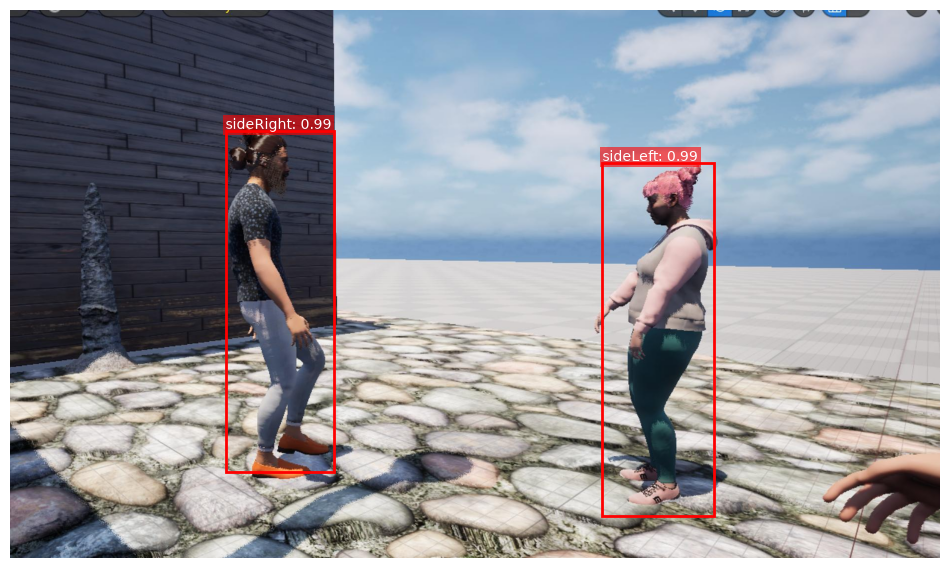

In [26]:
img, annotation = test_dataset[0]

np_img = np.array(img, dtype=np.float32) / 255.0
pixel_values = torch.from_numpy(np_img).permute(2, 0, 1).unsqueeze(0)
pixel_values = pixel_values.to(rcnn_adapter_reloaded.device)

rcnn_adapter_reloaded.model.eval()
with torch.no_grad():
    outputs = rcnn_adapter_reloaded.model([pixel_values[0]])

raw_results = outputs[0]

# SHIFT LABELS BACK DOWN BY -1
# This maps the model's indices (1 to 8) back to your dataset's indices (0 to 7)
shifted_labels = raw_results["labels"] - 1

results = {
    "boxes": raw_results["boxes"],
    "scores": raw_results["scores"],
    "labels": shifted_labels  # Use the shifted labels here!
}

# Now index 7 (original 8th class) will display its true category name!
plot_predictions(img, results, test_dataset, threshold=0.5)


## Train RetinaNet
RetinaNet can be imported from torchvision, too. Hence, we are going to use yet another Adapter model from the canonical dataset.

In [27]:
train_dataset.catid2label

{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}

In [28]:
# Observed problem: RetinaNet does not converge/converges randomly, sometimes giving errors about skipping batches due to NaN loss
# It might be exploding gradients problem, so Foccal loss bias init was added

dataset_classes = len(train_dataset.catid2label)
output_classes = dataset_classes 

retinanet_model = torchvision.models.detection.retinanet_resnet50_fpn_v2(
    weights=torchvision.models.detection.RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT,
    trainable_backbone_layers=3  # Unfreezes layer2, layer3, layer4
)
# Get setup metadata
num_anchors = retinanet_model.head.classification_head.num_anchors
in_channels = retinanet_model.head.classification_head.conv[0][0].in_channels

# Replace with your custom classification head
retinanet_model.head.classification_head = RetinaNetClassificationHead(
    in_channels,
    num_anchors,
    dataset_classes
)

# APPLY FOCAL LOSS BIAS INITIALIZATION 
# Base initialisation for all conv layers in custom head
for layer in retinanet_model.head.classification_head.modules():
    if isinstance(layer, nn.Conv2d):
        nn.init.normal_(layer.weight, std=0.01)
        nn.init.constant_(layer.bias, 0)

# Set the prior probability (pi) specifically on cls_logits to suppress early background spikes
pi = 0.01
prior_bias = -math.log((1 - pi) / pi)
nn.init.constant_(retinanet_model.head.classification_head.cls_logits.bias, prior_bias)


print(f'Num classes: {dataset_classes}')
print(f"In channels: {in_channels}")
print(f"Number of Retinanet classification classes: {retinanet_model.head.classification_head.num_classes}")
print(f"Number of Retinanet anchors: {retinanet_model.head.classification_head.num_anchors}")

print(train_dataset.catid2label)
retinanet_model.to(DEVICE)

Num classes: 8
In channels: 256
Number of Retinanet classification classes: 8
Number of Retinanet anchors: 9
{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}


RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True,

In the output, we see a Sigmoid_focal_loss applied for Retinanet_resnet50_fpn_v2 and no background class mapping.

In [29]:
class RetinaNetAdapter(BaseModelAdapter):
    def __init__(self, model, dataset_id2label, device=DEVICE):
        super().__init__(dataset_id2label = dataset_id2label, device=device)
        self.model = model

        print(f'Model: {self.model} \n Output classes: {self.output_classes} \n Device: {self.device}')

    def prepare_item(self, images, annotations):
        if annotations is not None:
            targets = self._get_annotations(images, annotations)
        else:
            targets = None
            
        tensor_images = []
        for img in images:
            np_img = np.array(img, dtype=np.float32) / 255.0
            tensor_images.append(torch.from_numpy(np_img).permute(2, 0, 1).to(self.device))
        return tensor_images, targets

    def build_id2label(self, dataset_id2label):
        # RetinaNet: no reserved background index, dataset labels pass through unshifted
        return dict(dataset_id2label)

    def eval_for_validation(self):
        self.model.train()
        for m in self.model.modules():
            if isinstance(m, torch.nn.modules.batchnorm._BatchNorm):
                m.eval()


    def forward_train(self, images, annotations):
        tensor_images, targets = self.prepare_item(images, annotations)

        loss_dict = self.model(tensor_images, targets)
        return sum(loss for loss in loss_dict.values())
    
    # inherit: predict
  

In [30]:
# define standard retinanet params
params = [p for p in retinanet_model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

len_dataloader = len(train_loader)

retinanet_adapter = RetinaNetAdapter(retinanet_model, train_dataset.id2label)
print(retinanet_model.head.classification_head.num_classes)


best_val_loss = float("inf")   # reset for RetinaNet
retinanet_train_losses, retinanet_val_losses = [], []

best_epoch = None
retinanet_best = None

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
        
    train_loss = train_one_epoch(retinanet_adapter, train_loader, optimizer)
    val_loss = validate_one_epoch(retinanet_adapter, val_loader)
    
    retinanet_train_losses.append(train_loss)
    retinanet_val_losses.append(val_loss)

    print(f"Epoch {epoch+1} Complete | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # simple save: If best val
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        retinanet_best = copy.deepcopy(retinanet_adapter)
        torch.save(retinanet_adapter.model.state_dict(), "models/retinanet_trained_weights.pth")
        print(f"  -> New best model saved (val_loss={val_loss:.4f})")

Model: RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affin

Training: 100%|██████████| 101/101 [00:27<00:00,  3.70it/s, batch_loss=0.8606]


Epoch 1 Complete | Train Loss: 0.9161 | Val Loss: 0.6271
  -> New best model saved (val_loss=0.6271)

--- Epoch 2/30 ---


Training: 100%|██████████| 101/101 [00:27<00:00,  3.69it/s, batch_loss=0.7586]


Epoch 2 Complete | Train Loss: 0.6346 | Val Loss: 0.6230
  -> New best model saved (val_loss=0.6230)

--- Epoch 3/30 ---


...

Epoch 28 Complete | Train Loss: 0.2353 | Val Loss: 0.3595

--- Epoch 29/30 ---


Training: 100%|██████████| 101/101 [00:27<00:00,  3.71it/s, batch_loss=0.3544]


Epoch 29 Complete | Train Loss: 0.2188 | Val Loss: 0.3341

--- Epoch 30/30 ---


Training: 100%|██████████| 101/101 [00:27<00:00,  3.65it/s, batch_loss=0.1974]
                                                           

Epoch 30 Complete | Train Loss: 0.2380 | Val Loss: 0.3355


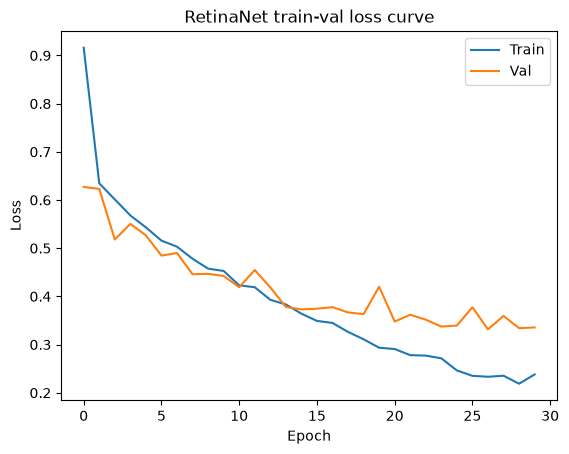

In [31]:
plot_train_val_loss_curve(retinanet_train_losses, retinanet_val_losses, "RetinaNet train-val loss curve")

In [32]:
retinanet_adapter.id2label

{0: 'backLeft',
 1: 'backRight',
 2: 'backStraight',
 3: 'frontLeft',
 4: 'frontRight',
 5: 'frontStraight',
 6: 'sideLeft',
 7: 'sideRight'}

In [33]:
show_mAP(retinanet_best, test_loader, False, DEVICE)

   Object Detection Evaluation    
             Results              
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric / Class        ┃  Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Global mAP (0.5:0.95) │ 0.3493 │
│ mAP @ 50              │ 0.4077 │
│ mAP @ 75              │ 0.4077 │
├───────────────────────┼────────┤
│ backLeft              │ 0.0000 │
│ backRight             │ 0.2856 │
│ backStraight          │ 0.5226 │
│ frontLeft             │ 0.2067 │
│ frontRight            │ 0.3997 │
│ frontStraight         │ 0.6783 │
│ sideLeft              │ 0.3060 │
│ sideRight             │ 0.3953 │
└───────────────────────┴────────┘

In [34]:
label_counts = Counter()
for _, ann in train_dataset:
    label_counts.update(ann["labels"].tolist())
for i, name in train_dataset.id2label.items():
    print(f"{name}: {label_counts.get(i, 0)}")

backLeft: 94
backRight: 116
backStraight: 141
frontLeft: 151
frontRight: 137
frontStraight: 196
sideLeft: 159
sideRight: 159


Building confusion matrix: 100%|██████████| 15/15 [00:02<00:00,  7.34it/s]


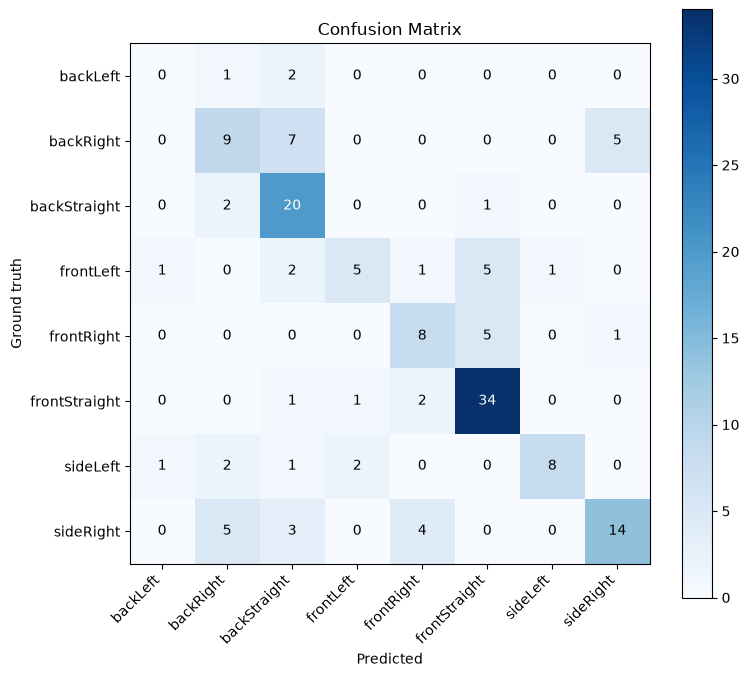

tensor([[ 0,  1,  2,  0,  0,  0,  0,  0],
        [ 0,  9,  7,  0,  0,  0,  0,  5],
        [ 0,  2, 20,  0,  0,  1,  0,  0],
        [ 1,  0,  2,  5,  1,  5,  1,  0],
        [ 0,  0,  0,  0,  8,  5,  0,  1],
        [ 0,  0,  1,  1,  2, 34,  0,  0],
        [ 1,  2,  1,  2,  0,  0,  8,  0],
        [ 0,  5,  3,  0,  4,  0,  0, 14]])

In [35]:
plot_confusion_matrix(
    adapter=retinanet_best, 
    dataloader=test_loader, 
    id2label=retinanet_best.id2label, 
    include_background=False, # No background token tracked in RetinaNet's outputs
    iou_threshold=0.3,
    score_threshold=0.3
)

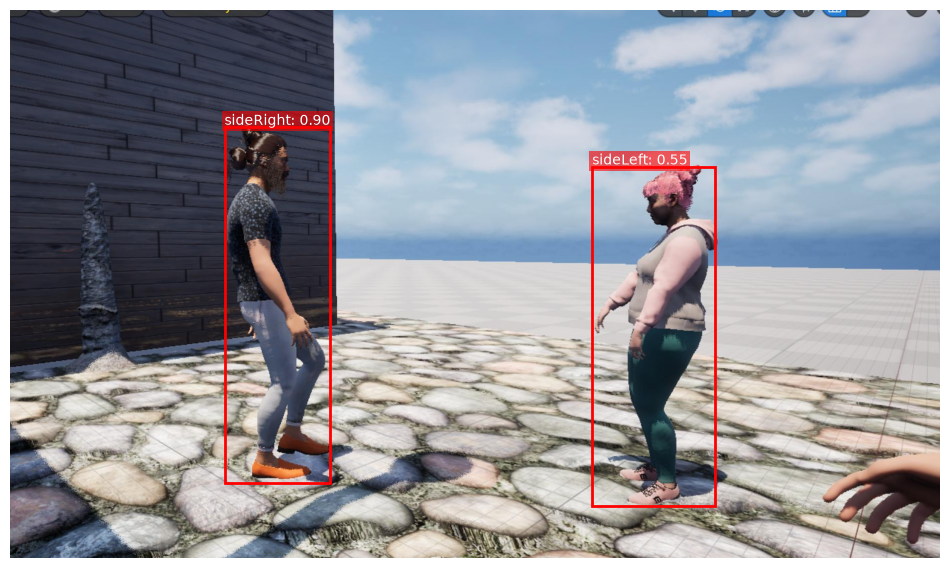

In [36]:
img, annotation = test_dataset[0]

# Prepare image (same float scaled [0, 1] tensor format as Faster R-CNN)
np_img = np.array(img, dtype=np.float32) / 255.0
pixel_values = torch.from_numpy(np_img).permute(2, 0, 1).unsqueeze(0)
pixel_values = pixel_values.to(retinanet_adapter.device)

retinanet_adapter.model.eval()
with torch.no_grad():
    outputs = retinanet_adapter.model([pixel_values[0]])

raw_results = outputs[0]

results = {
    "boxes": raw_results["boxes"],
    "scores": raw_results["scores"],
    "labels": raw_results["labels"] 
}

plot_predictions(img, results, test_dataset, threshold=0.5)

## Train DETR
DETR is currently not supported by the torchvision framework. However, a derivate is available in the hugging face libraries. As Hugging face is open-source and readily integratable, we will be using their libraries.<br>
DETR expects COCO annotations.

In [37]:
# idea: Move dataset conversions to its own functions so we can have a look into the outputs
class DETRAdapter(BaseModelAdapter):
    def __init__(self, model, dataset_id2label, processor):
        super().__init__(dataset_id2label=dataset_id2label, device=DEVICE)
        self.model = model.to(self.device)
        self.processor = processor

        print(f'Model: {self.model} \n Num classes: {self.output_classes} \n Device: {self.device}')
        

    def prepare_item(self, images, annotations):
        if annotations is None:
            # Inference path
            encoded_items = []
            for img in images:
                np_img = np.array(img)
                encoded = self.processor(images=np_img, return_tensors="pt")
                encoded = {
                    k: v.squeeze(0) if isinstance(v, torch.Tensor) else v[0]
                    for k, v in encoded.items()
                }
                encoded_items.append(encoded)
            return encoded_items

        # Training path
        encoded_items = []
        for img, target in zip(images, annotations):
            image_id = target["image_id"].item() if isinstance(target["image_id"], torch.Tensor) else target["image_id"]
            
            # target["boxes"] is [x1, y1, x2, y2] (VOC)
            boxes = target["boxes"].tolist()
            labels = target["labels"].tolist()

            anno_list = []
            for box, label in zip(boxes, labels):
                x1, y1, x2, y2 = box
                w = max(0.0, x2 - x1)
                h = max(0.0, y2 - y1)
                anno_list.append({
                    "image_id": image_id,
                    "category_id": label,
                    "bbox": [x1, y1, w, h],  # COCO format [x_min, y_min, width, height]
                    "iscrowd": 0,
                    "area": w * h,
                })

            formatted_annotations = {
                "image_id": image_id,
                "annotations": anno_list,
            }

            np_img = np.array(img)
            encoded = self.processor(
                images=np_img,
                annotations=formatted_annotations,
                return_tensors="pt"
            )
            encoded = {
                k: v.squeeze(0) if isinstance(v, torch.Tensor) else v[0]
                for k, v in encoded.items()
            }
            encoded_items.append(encoded)

        return encoded_items


    # like base
    def eval_for_validation(self):
        self.model.eval()

    def build_id2label(self, dataset_id2label):
        # pass through
        return dict(dataset_id2label)


    def forward_train(self, images, annotations):
        encoded_items = self.prepare_item(images, annotations)

        # Move pixel values to GPU
        pixel_values = torch.stack(
            [item["pixel_values"] for item in encoded_items]
        ).to(self.device)

        detr_labels = []
        for item in encoded_items:
            device_labels = {
                k: v.to(self.device) if isinstance(v, torch.Tensor) else v 
                for k, v in item["labels"].items()
            }
            # Indent this so EVERY item in the batch is added to the list
            detr_labels.append(device_labels)

        # Forward pass through the model
        outputs = self.model(
            pixel_values=pixel_values,
            labels=detr_labels,
        )

        return outputs.loss
        
    @torch.no_grad()
    def predict(self, images, score_threshold=0.1):
        self.model.eval()
        encoded_items = self.prepare_item(images, annotations=None)
        pixel_values = torch.stack(
            [item["pixel_values"] for item in encoded_items]
        ).to(self.device)

        outputs = self.model(pixel_values=pixel_values)

        target_sizes = torch.tensor([img.size[::-1] for img in images]).to(self.device)
        results = self.processor.post_process_object_detection(
            outputs, target_sizes=target_sizes, threshold=score_threshold
        )
        return results

In [38]:
CHECKPOINT = "PekingU/rtdetr_v2_r50vd"
IMAGE_SIZE = 832

label2id = {v: k for k, v in train_dataset.id2label.items()}
assert len(label2id) == len(train_dataset.id2label), "duplicate class names — label2id would lose entries" # Guard against silent error

detr_model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=train_dataset.id2label,
    label2id=label2id,
    anchor_image_size=None,
    ignore_mismatched_sizes=True,
)

detr_processor = AutoImageProcessor.from_pretrained(
    CHECKPOINT,
    do_resize=True,
    size={"width": IMAGE_SIZE, "height": IMAGE_SIZE},)


detr_adapter = DETRAdapter(detr_model, train_dataset.id2label, detr_processor)


Some weights of RTDetrV2ForObjectDetection were not initialized from the model checkpoint at PekingU/rtdetr_v2_r50vd and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([8]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([8, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([8]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([8, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([8]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([8, 256]) in the model instantiated
- model.decod

Model: RTDetrV2ForObjectDetection(
  (model): RTDetrV2Model(
    (backbone): RTDetrV2ConvEncoder(
      (model): RTDetrResNetBackbone(
        (embedder): RTDetrResNetEmbeddings(
          (embedder): Sequential(
            (0): RTDetrResNetConvLayer(
              (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (normalization): RTDetrV2FrozenBatchNorm2d()
              (activation): ReLU()
            )
            (1): RTDetrResNetConvLayer(
              (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (normalization): RTDetrV2FrozenBatchNorm2d()
              (activation): ReLU()
            )
            (2): RTDetrResNetConvLayer(
              (convolution): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (normalization): RTDetrV2FrozenBatchNorm2d()
              (activation): ReLU()
            )
          )
          (

In [39]:
img, ann = train_dataset[0]
encoded = detr_adapter.prepare_item([img], [ann])

print("Image Tensor Shape:", encoded[0]["pixel_values"].shape)
print("Target Boxes:", encoded[0]["labels"]["boxes"])
print("Target Class Labels:", encoded[0]["labels"]["class_labels"])

Image Tensor Shape: torch.Size([3, 832, 832])
Target Boxes: tensor([[0.2164, 0.5597, 0.1841, 0.8597],
        [0.9023, 0.3076, 0.1472, 0.4682]])
Target Class Labels: tensor([7, 1])


In [40]:
img, ann = test_dataset[0]
print("PIL image size (w,h):", img.size)
print("GT boxes (first one):", ann["boxes"][0])

PIL image size (w,h): (1875, 1105)
GT boxes (first one): tensor([430.0000, 231.6700, 648.3300, 943.3400])


In [41]:
params = [p for p in detr_model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(      # train DETR with AdamW instead
    detr_model.parameters(),
    lr=3e-5,
    weight_decay=1e-4,
)

len_dataloader = len(train_loader)

best_val_loss = float("inf")    # reset for rtdetr
detr_train_losses, detr_val_losses = [], []

best_epoch = None
detr_best = None

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")

    train_loss = train_one_epoch(detr_adapter, train_loader, optimizer)
    val_loss = validate_one_epoch(detr_adapter, val_loader)

    detr_train_losses.append(train_loss)
    detr_val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1} Complete | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # simple save: If best val
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        detr_best = copy.deepcopy(detr_adapter)
        torch.save(detr_adapter.model.state_dict(), "models/detr_trained_weights.pth")
        print(f"  -> New best model saved (val_loss={val_loss:.4f})")


--- Epoch 1/30 ---


Training: 100%|██████████| 101/101 [00:29<00:00,  3.42it/s, batch_loss=34.9023]


Epoch 1 Complete | Train Loss: 58.9764 | Val Loss: 21.3415
  -> New best model saved (val_loss=21.3415)

--- Epoch 2/30 ---


Training: 100%|██████████| 101/101 [00:28<00:00,  3.58it/s, batch_loss=23.3708]


Epoch 2 Complete | Train Loss: 28.5962 | Val Loss: 13.8390
  -> New best model saved (val_loss=13.8390)

--- Epoch 3/30 ---


...

Epoch 28 Complete | Train Loss: 10.3565 | Val Loss: 9.6001

--- Epoch 29/30 ---


Training: 100%|██████████| 101/101 [00:29<00:00,  3.45it/s, batch_loss=9.9750]


Epoch 29 Complete | Train Loss: 10.3805 | Val Loss: 8.8040

--- Epoch 30/30 ---


Training: 100%|██████████| 101/101 [00:29<00:00,  3.46it/s, batch_loss=9.5149]
                                                           

Epoch 30 Complete | Train Loss: 9.8498 | Val Loss: 8.7720


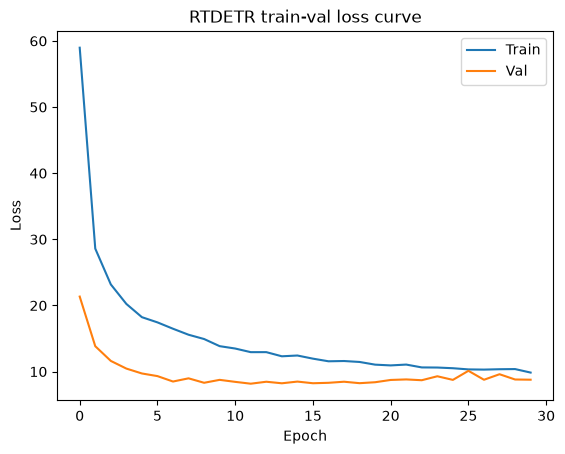

In [42]:
plot_train_val_loss_curve(detr_train_losses, detr_val_losses, "RTDETR train-val loss curve")

In [43]:
detr_adapter.id2label

{0: 'backLeft',
 1: 'backRight',
 2: 'backStraight',
 3: 'frontLeft',
 4: 'frontRight',
 5: 'frontStraight',
 6: 'sideLeft',
 7: 'sideRight'}

In [44]:
show_mAP(detr_best, test_loader, False, DEVICE)

   Object Detection Evaluation    
             Results              
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric / Class        ┃  Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Global mAP (0.5:0.95) │ 0.5950 │
│ mAP @ 50              │ 0.7137 │
│ mAP @ 75              │ 0.6844 │
├───────────────────────┼────────┤
│ backLeft              │ 0.7626 │
│ backRight             │ 0.4470 │
│ backStraight          │ 0.6326 │
│ frontLeft             │ 0.4460 │
│ frontRight            │ 0.5646 │
│ frontStraight         │ 0.6446 │
│ sideLeft              │ 0.5333 │
│ sideRight             │ 0.7295 │
└───────────────────────┴────────┘

Building confusion matrix: 100%|██████████| 15/15 [00:01<00:00,  7.67it/s]


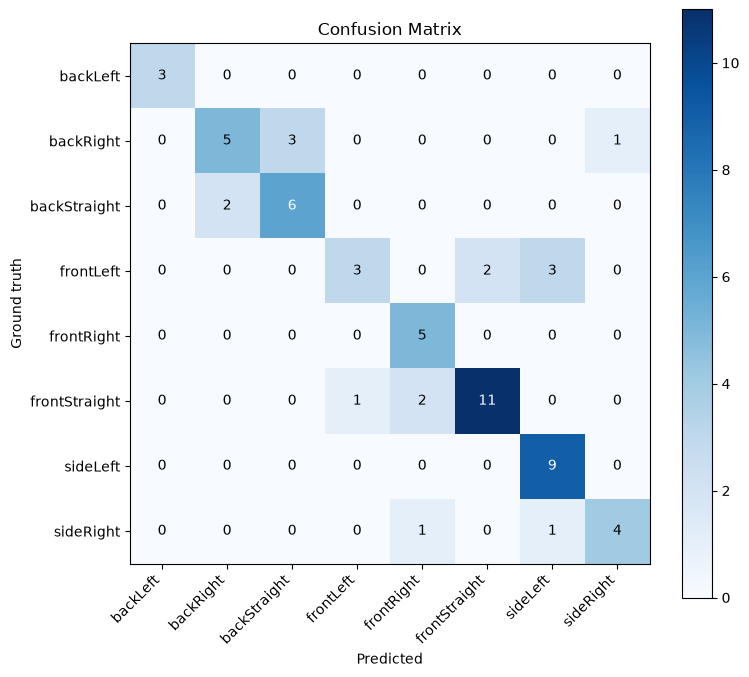

In [45]:
cm = plot_confusion_matrix(detr_best, 
                           test_loader, 
                           id2label=detr_best.id2label, 
                           include_background=False, 
                           iou_threshold=0.3, 
                           score_threshold=0.3)

In [46]:
# since backLeft is severely underrepresented, investigate the labels if they are ok
# Count backLeft boxes before vs after processor, on the test set specifically
BACKLEFT_IDX = 0

raw_count = 0
for i in range(len(test_dataset)):
    _, target = test_dataset[i]
    raw_count += (target["labels"] == BACKLEFT_IDX).sum().item()

processed_count = 0
for i in range(len(test_dataset)):
    img, ann = test_dataset[i]
    encoded = detr_adapter.prepare_item([img], [ann])
    processed_count += (encoded[0]["labels"]["class_labels"] == BACKLEFT_IDX).sum().item()

print(f"backLeft - raw: {raw_count}, after DETR processor: {processed_count}")

print(detr_model.config.id2label)
print(train_dataset.id2label)
assert detr_model.config.id2label == train_dataset.id2label, "Mismatch between model config and dataset label mapping!"

label_counts = Counter()
for i in range(len(train_dataset)):
    _, target = train_dataset[i]
    label_counts.update(target["labels"].tolist())
print(sorted(label_counts.items()))

# check predicted classes:
pred_counter = Counter()

for images, _ in test_loader:
    preds = detr_adapter.predict(images)
    for pred in preds:
        pred_counter.update(pred["labels"].cpu().tolist())

print(pred_counter) # RT DETR never predicted backLeft


encoded = detr_adapter.prepare_item([img], [ann])


counter = Counter()

for images, anns in train_loader:
    encoded = detr_adapter.prepare_item(images, anns)

    for sample in encoded:
        labels = sample["labels"]["class_labels"].cpu().tolist()
        counter.update(labels)

print(counter)


backLeft - raw: 8, after DETR processor: 8
{0: 'backLeft', 1: 'backRight', 2: 'backStraight', 3: 'frontLeft', 4: 'frontRight', 5: 'frontStraight', 6: 'sideLeft', 7: 'sideRight'}
{0: 'backLeft', 1: 'backRight', 2: 'backStraight', 3: 'frontLeft', 4: 'frontRight', 5: 'frontStraight', 6: 'sideLeft', 7: 'sideRight'}
[(0, 94), (1, 116), (2, 141), (3, 151), (4, 137), (5, 196), (6, 158), (7, 159)]
Counter({5: 47, 7: 34, 3: 31, 2: 30, 6: 27, 0: 27, 1: 18, 4: 18})
Counter({5: 196, 7: 159, 6: 159, 3: 151, 2: 141, 4: 137, 1: 116, 0: 94})


In [47]:
for images, anns in test_loader:
    preds = detr_adapter.predict(images)

    for pred, ann in zip(preds, anns):
        gt_mask = ann["labels"] == 0

        if not gt_mask.any():
            continue

        gt_boxes = ann["boxes"][gt_mask].to(pred["boxes"].device)
        ious = box_iou(gt_boxes, pred["boxes"])

        for i, gt_box in enumerate(gt_boxes):
            if ious.shape[1] == 0:
                print("No predictions")
                continue

            best = ious[i].argmax()
            print(
                "Predicted class:", pred["labels"][best].item(),
                "score:", pred["scores"][best].item(),
                "IoU:", ious[i, best].item(),
            )

Predicted class: 0 score: 0.3054099977016449 IoU: 0.9836012721061707
Predicted class: 0 score: 0.29347681999206543 IoU: 0.9208198189735413
Predicted class: 0 score: 0.31189432740211487 IoU: 0.942783534526825
Predicted class: 0 score: 0.3283229172229767 IoU: 0.9356887936592102
Predicted class: 0 score: 0.3128485083580017 IoU: 0.9343719482421875
Predicted class: 0 score: 0.2547799348831177 IoU: 0.836088240146637
Predicted class: 0 score: 0.28433579206466675 IoU: 0.9867678880691528
Predicted class: 0 score: 0.31759560108184814 IoU: 0.9698843359947205


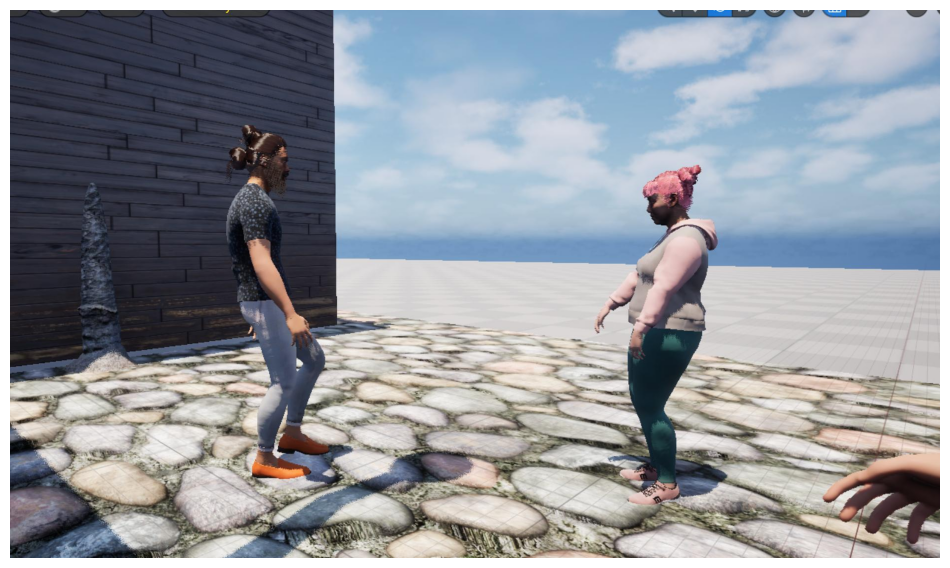

In [48]:
img, annotation = test_dataset[0]

inputs = detr_adapter.processor(images=img, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(detr_adapter.device)

with torch.no_grad():
    outputs = detr_adapter.model(pixel_values=pixel_values)

target_sizes = torch.tensor([img.size[::-1]]).to(detr_adapter.device)
results = detr_adapter.processor.post_process_object_detection(
    outputs, target_sizes=target_sizes, threshold=0.1 # Keep low here, let the function filter it
)[0]

plot_predictions(img, results, test_dataset, threshold=0.5)

In [49]:
print(detr_model.config.id2label)
print(train_dataset.id2label)
assert detr_model.config.id2label == train_dataset.id2label, "Mismatch between model config and dataset label mapping!"

label_counts = Counter()
for i in range(len(train_dataset)):
    _, target = train_dataset[i]
    label_counts.update(target["labels"].tolist())
print(sorted(label_counts.items()))

{0: 'backLeft', 1: 'backRight', 2: 'backStraight', 3: 'frontLeft', 4: 'frontRight', 5: 'frontStraight', 6: 'sideLeft', 7: 'sideRight'}
{0: 'backLeft', 1: 'backRight', 2: 'backStraight', 3: 'frontLeft', 4: 'frontRight', 5: 'frontStraight', 6: 'sideLeft', 7: 'sideRight'}
[(0, 94), (1, 116), (2, 141), (3, 150), (4, 137), (5, 196), (6, 159), (7, 159)]


Comparison and Evaluation

All models trained with overfitting. 

In [50]:
print("rcnn_adapter")
show_mAP(rcnn_adapter, val_loader, True, DEVICE)
print("retinanet_adapter")
show_mAP(retinanet_adapter, val_loader, True, DEVICE)
print("detr_adapter")
show_mAP(detr_adapter, val_loader, True, DEVICE)

rcnn_adapter


   Object Detection Evaluation    
             Results              
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric / Class        ┃  Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Global mAP (0.5:0.95) │ 0.5230 │
│ mAP @ 50              │ 0.6907 │
│ mAP @ 75              │ 0.6464 │
├───────────────────────┼────────┤
│ background            │ 0.2949 │
│ backLeft              │ 0.4412 │
│ backRight             │ 0.6526 │
│ backStraight          │ 0.4799 │
│ frontLeft             │ 0.6007 │
│ frontRight            │ 0.7006 │
│ frontStraight         │ 0.5394 │
│ sideLeft              │ 0.4750 │
└───────────────────────┴────────┘

retinanet_adapter


   Object Detection Evaluation    
             Results              
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric / Class        ┃  Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Global mAP (0.5:0.95) │ 0.4380 │
│ mAP @ 50              │ 0.5080 │
│ mAP @ 75              │ 0.4922 │
├───────────────────────┼────────┤
│ backLeft              │ 0.0676 │
│ backRight             │ 0.2433 │
│ backStraight          │ 0.6430 │
│ frontLeft             │ 0.4562 │
│ frontRight            │ 0.6458 │
│ frontStraight         │ 0.7219 │
│ sideLeft              │ 0.3007 │
│ sideRight             │ 0.4255 │
└───────────────────────┴────────┘

detr_adapter


   Object Detection Evaluation    
             Results              
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric / Class        ┃  Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Global mAP (0.5:0.95) │ 0.5933 │
│ mAP @ 50              │ 0.6651 │
│ mAP @ 75              │ 0.6367 │
├───────────────────────┼────────┤
│ backLeft              │ 0.4158 │
│ backRight             │ 0.4289 │
│ backStraight          │ 0.7558 │
│ frontLeft             │ 0.5844 │
│ frontRight            │ 0.6798 │
│ frontStraight         │ 0.7754 │
│ sideLeft              │ 0.5183 │
│ sideRight             │ 0.5877 │
└───────────────────────┴────────┘

| Metric      | FasterRCNN | RetinaNet | RT-DETR |
|--------------|-----------:|----------:|---------:|
| mAP (.5:.95) | 0.523 | 0.438 | **0.593** |
| mAP@50       | **0.691** | 0.508 | 0.665 |
| mAP@75       | **0.646** | 0.492 | 0.637 |

The overall detection performance post training of 25 epochs showed overfitting for all models. It is suggested, that this has been due to the small dataset containing only 403 images in the train, 115 images in the validation set for a 8 class classification.<br>
The class imbalances with the smalles samples in backLeft and backRight did particularly affect FasterRCNN (Ratio detected RP/FP: 8/10) and RetinaNET (Ratio detected RP/FP: 0/2).<br>
FasterRCNN and RetinaNet showed overfitting: FasterRCNN, opened the gap from Epoch 5, RetinaNet from Epoch 13,   RT-DETR from 11, leading to the best model saved at epchs 11, 20 and at 12. Therefore, all final models were only trained at very few epochs.<br>
Regarding the mAP, RT-DETR and FasterRCNN trade-off: RT-DETR predicts BBoxes precisely (highest IoU between 0.83-0.99), but at low confidence. In fact, setting confidence thresholds to 0.5 like for FasterRCNN and RetinaNet would wipe all true positives. FasterRCNN mAP table holds a small bug, where background instead of SightRight is displayed. Nevertheless, the mAP@50 shows the overall classification had the best results at higher confidence rates (>0.5). The background class however is often predicted, showing real-world failure between No-Object and Some-Object. RetinaNet was weaker over all.<br>

### Evaluation: RetinaNet Training Dynamics
The feature extraction backbone of RetinaNet were loaded from RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT checkpoint, with layers 2 to 4 unfrozen for fine-tuning.<br>
RetinaNet was the only model, for which the entire convolutional head was changed. It therefore required prior bias initialisation. This is a lessons learned, as at first gradients exploded, due to anchor-dense detector evaluating great numbers of candidate regions, calculating initial losses on uncalibrated background predictions.<br>
In addition, this behaviour is promoted by the single-stage detector architecture, which predicts great numbers of anchors of which the vast majority initially corresponds to background. Consequently, in early stages, there is a severe imbalance towards background detections. Focal Loss addresses this issue by applying a modulating factor, that dynamically down-weights well-classified examples. This suppresses the gradient contribution of background predictions and forces the optimisation process to focus on ambiguous regions (Note: In contrast, Cross-Entropy loss is overpowered by sheer volume of background anchors).<br>
During training it became obvious that the single-stage, anchor-based RetinaNet required a greater number (>20) of training epochs, until useful classifications were established.


### Evaluation: FasterRCNN Training Dynamics
Positioned between the single-stage RetinaNet and the transformer-based RT-DETR, Faster R-CNN demonstrated moderate convergence speed, stabilizing around the [X]th epoch. It was initialised from pre-trained FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT checkpoint. The head was changed to FastRCNNPredictor trained from scratch for the 8 object classes plus one background class (1024 features). Weights are partially frozed, with layers 2 to 4 unfrozen for fine-tuning (like RetinaNet).<br>
It uses a two-stage architecture containing a Region Proposal Network (RPN) and Fast R-CNN Head. Structurally, Faster R-CNN avoids the early gradient swamping of RetinaNet through its two-stage architecture. The pre-trained RPN filters the overwhelming background anchors in Stage 1, feeding a sparse set of candidates to Stage 2. Consequently, the training stabilises earlier without requiring specialised prior bias initialisations.

### Evaluation: RT-DETR Training Dynamics
In contrast to the anchor-based architectures, RT-DETR converged quickly,stagnating after the []th Epoch onwards.<br>
The rapid stabilisation was aided by transfer learning from the PekingU/rtdetr_v2_r50vd checkpoint. Because the feature extraction backbone, attention matrices and bounding box regression layers were fully pre-trained on COCO, training primarily required fine-tuning the newly initialized 8-class prediction heads (class_embed and enc_score_head).<br>
RT-DETR required resizing the images. Changing from the size 640 to 832, helped model performance. Also, the rapid stabilisation was traded against slower, but higher resolution convergence from lr=5e-5 to lr=3e-5. Notabely, the confidence in predictions are really low (e.g. ~0.25-0.32 on class 0), which required to raise predictions thresholds, as for 0.5 all predictions were neglected at first.<br>
Furthermore, RT-DETR converged quickly thanks to the efficient attention mechanism. Unlike vanilla DETRs that apply full self-attention across all spatial scales, RT-DETR uses an Efficient Hybrid Encoder that restricts self-attention to high-level semantic features, which combined with IoU-aware query selection quickly provides precise object proposals to the decoder.<br>


## Conclusion
All three architectures overfit within a small number of epochs, confirming that dataset scale rather than architecture choice was the dominant constraint in this experiment. With only 403 training and 115 validation images spread across 8 imbalanced classes, no model was able to sustain improvement past epoch 20. The rare classes (backLeft, backRight) were consistently the hardest for every architecture to learn.<br>
The three models nonetheless diverged in how they overfit, consistent with their underlying design. RetinaNet's anchor-dense, single-stage formulation required the longest stabilisation period and was most exposed to the background-anchor imbalance inherent to its architecture. It produced the weakest final metrics across mAP, mAP@50 and mAP@75, making it the least suitable candidate. FasterRCNN's two-stage design, which filters background anchors via the RPN before classification, stabilised earlier and achieved the strongest mAP@50 of the three. However, its usefulness is undercut by a real classification failure: the background class is frequently predicted in place of true object classes, which in a deployment context is precisely the No-Object vs Some-Object distinction the model needs to get right. RT-DETR, benefiting from full COCO pretraining, converged fastest and achieved the highest global mAP (0.5:0.95), but its prediction confidences are systematically miscalibrated: true positives at IoU 0.83–0.99 scoring as low as 0.25–0.32 — meaning it cannot be used with a conventional 0.5 threshold without discarding nearly all correct detections.<br><br>
All three models currently trade-off for deployment, leading to the following recommendations:
<ol>
    <li>If a model needs to work at a standard confidence threshold with no further calibration, FasterRCNN is the most usable out of the box, provided the background-confusion failure mode is addressed (e.g. via additional negative/background training examples or a revised RPN threshold).
    <li>If localisation and classification quality are the priority and a custom, lowered confidence threshold (or a calibration step such as temperature scaling) is acceptable, RT-DETR delivers the strongest raw performance.
    <li>RetinaNet is not recommended for this task in its current form; it was outperformed on every metric despite requiring comparable or greater training effort to stabilise.
</ol>

## Future Improvements
The shared overfitting pattern across all three architectures points to dataset size and class balance, rather than model selection, as the primary lever for improving performance. Before further architecture comparison is meaningful, it is recommended to expand the training set (particularly for backLeft/backRight), correcting the class-index bug in the FasterRCNN evaluation table and applying confidence calibration to RT-DETR so its raw detection quality can be fairly compared against the other two at a shared operating threshold.